<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/10_exgaussian_default_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 10 — Priors that ignore the log link

Notebook 9 chose its priors for a typical participant's Gaussian standard deviation and for the tail mean in milliseconds, and only then translated them to the log scale on which the model uses them; its prior for how much participants differ was a ratio carried over from Notebook 8.

This notebook keeps Notebook 9's model and changes those three priors. They are written directly on the log scale, as wide distributions that look cautious on paper, and are never translated into milliseconds: the kind of prior written by default rather than by thinking about the quantity it constrains. The priors are chosen for you as a deliberate demonstration, not as a recommendation. The purpose of this notebook is to see what they actually say about reaction times, whether the workflow would have caught them before fitting, and what they do to the fit when that check is skipped.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper from the previous notebooks is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument. Panels appear in participant order (308, 309, …, 372), left to right and top to bottom.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Priors that ignore the link

### 1.1 The model

The model is Notebook 9's:

$$
y_i \sim \operatorname{ExGaussian}(\mu_{y,i}, sd_{y,s[i]}, \nu)
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
\log sd_{y,s}
\sim
\operatorname{Normal}(\mu_{\log sd_y}, sd_{\log sd_y}),
$$

with Notebook 5's hierarchies for $b_{0,s}$ and $b_{1,s}$ and one tail mean $\nu$ shared by all participants. Only three priors change, all of them for parameters that the model uses on the log scale:

| Parameter | Notebook 9 | This notebook |
|---|---|---|
| `mu_log_sd_y`, $\mu_{\log sd_y}$ | $\operatorname{Normal}(\log 30, 0.5)$ | $\operatorname{Normal}(0, 5)$ |
| `sd_log_sd_y`, $sd_{\log sd_y}$ | $\operatorname{Exponential}(\mathrm{scale}=1/3)$ | $\operatorname{Exponential}(\mathrm{scale}=5)$ |
| `log_nu`, $\log \nu$ | $\operatorname{Normal}(\log 50, 0.75)$ | $\operatorname{Normal}(0, 5)$ |

The mean structure and its priors, the construction of `sd_y` and `nu`, and the likelihood are unchanged.

### 1.2 The supplied model

The whole model is supplied in one cell. It is Notebook 9's code with the three new prior constants; Notebook 9's values are shown in the comments. Notebook 9's `mean_rt` is left out, because no question here uses it.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy (ms), from Notebook 5
mu_mu_b0 = 250
sd_mu_b0 = 100
sd_sd_b0 = 25

# Hyperprior constants for the slope hierarchy (ms/day), from Notebook 5
mu_mu_b1 = 0
sd_mu_b1 = 20
sd_sd_b1 = 10

# Naive prior constants, written directly on the log scale
mu_mu_log_sd_y = 0  # Notebook 9: np.log(30)
sd_mu_log_sd_y = 5  # Notebook 9: 0.5
sd_sd_log_sd_y = 5  # Notebook 9: 1 / 3
mu_log_nu = 0       # Notebook 9: np.log(50)
sd_log_nu = 5       # Notebook 9: 0.75

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes
    mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")

    # Location of the Gaussian part (ms)
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )

    # Participants' Gaussian standard deviations, with a log link
    mu_log_sd_y = pm.Normal("mu_log_sd_y", mu=mu_mu_log_sd_y, sigma=sd_mu_log_sd_y)
    sd_log_sd_y = pm.Exponential("sd_log_sd_y", scale=sd_sd_log_sd_y)
    log_sd_y = pm.Normal(
        "log_sd_y",
        mu=mu_log_sd_y,
        sigma=sd_log_sd_y,
        dims="participant",
    )
    sd_y = pm.Deterministic("sd_y", pm.math.exp(log_sd_y), dims="participant")

    # Shared tail mean, with a log link
    log_nu = pm.Normal("log_nu", mu=mu_log_nu, sigma=sd_log_nu)
    nu = pm.Deterministic("nu", pm.math.exp(log_nu))

    y = pm.ExGaussian(
        "y",
        mu=mu_y,
        sigma=sd_y[pidx],
        nu=nu,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 1.3 What does $\log \nu \sim \operatorname{Normal}(0, 5)$ say about the tail mean in milliseconds?

In Notebook 9 (Question 1.12), we started from a range in milliseconds and translated it to the log scale. Go the other way. What median tail mean does this prior imply, and between which values does it put about 95% of its probability? Compare with Notebook 9's plausible range of about 11–220 ms.

Exponentiating the center of a log-scale Normal gives the median (Notebook 9, Question 2.4), so the median tail mean is $e^0 = 1$ ms. About 95% of the probability lies within $0 \pm 2(5)$ on the log scale, between $e^{-10} \approx 0.00005$ ms and $e^{10} \approx 22{,}000$ ms, or 22 s: almost nine orders of magnitude. Notebook 9's plausible range of 11–220 ms, which held 95% of its prior, holds only about 18% of this one. Half of this prior lies below 1 ms, a tail too short to matter, and about 8% lies above a full second.

A center of zero looks neutral, but on the log scale it is a definite claim: a typical tail of 1 ms. The prior for `mu_log_sd_y` is the same distribution, so it says the same about a typical participant's Gaussian standard deviation, where Notebook 9 expected about 30 ms.

### 1.4 What does $sd_{\log sd_y} \sim \operatorname{Exponential}(\mathrm{scale}=5)$ say about differences between participants?

In Notebook 9 (Question 1.10), the prior for `sd_log_sd_y` carried over from Notebook 8 unchanged because it is unit-free: participants' Gaussian standard deviations differ by a factor of $e^{sd_{\log sd_y}}$ per between-participant standard deviation, whatever the units of `sd_y`. What factor does this prior's mean, 5, imply? Does unit-free mean that any value is harmless?

At the prior mean of 5, participants' Gaussian standard deviations differ by a factor of $e^5 \approx 150$ per between-participant standard deviation, against $e^{1/3} \approx 1.4$ in Notebook 9. If a typical participant's Gaussian standard deviation were 30 ms, participants one between-participant standard deviation below and above the typical one would have Gaussian standard deviations of about 0.2 ms and 4.5 s.

No. Unit-free is not the same as meaning-free: on the log scale every number is a ratio, and 5 is a ratio of about 150.

## 2. Check the prior implications

### 2.1 Criteria

The criteria are Notebook 9's (Question 2.1 there):

1. predicted reaction times should not routinely be physically impossible;
2. reaction times near baseline should mostly occupy a broadly plausible range;
3. the model should allow substantial change across the seven days without routinely generating absurd trajectories;
4. the residual-scale hierarchy should allow participants to differ noticeably in day-to-day variability without making enormous differences routine;
5. the tail prior should allow anything from an almost symmetric distribution to a clearly right-skewed one without making tails of several hundred milliseconds routine.

The first three were established in Notebook 1. The mean-structure priors are Notebook 9's, so any new failure comes from the three log-scale priors.

### 2.2 Draw from the prior.

The draws of `mu_log_sd_y` and `log_nu` are kept for Section 4.

In [6]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["mu_log_sd_y", "log_nu", "y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, log_nu, log_sd_y, mu_b0, mu_b1, mu_log_sd_y, sd_b0, sd_b1, sd_log_sd_y, y]


### 2.3 Plot the prior predictive reaction times.

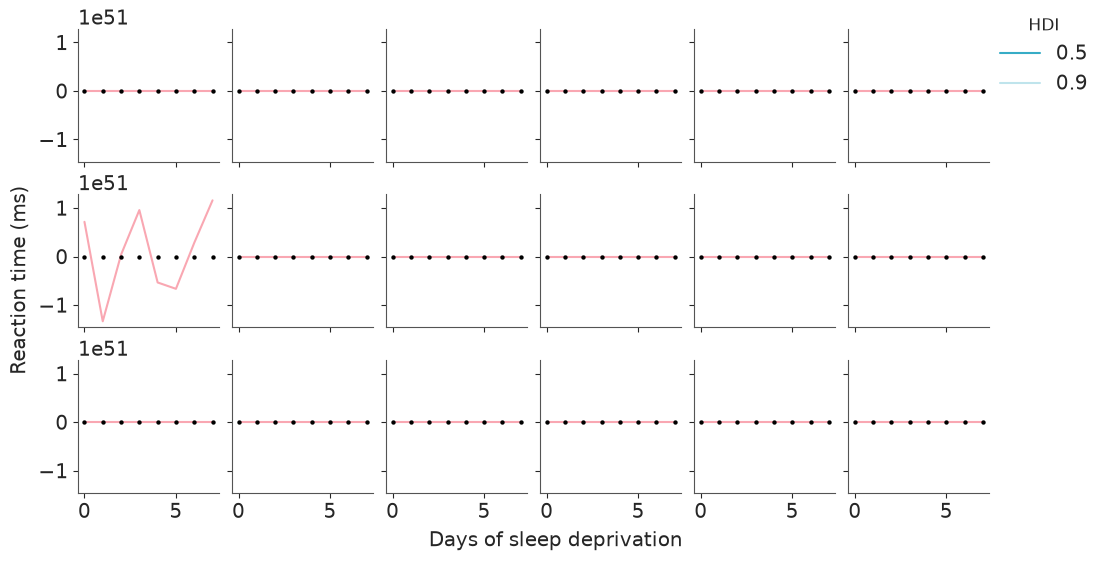

In [7]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.4 What does this plot show?

Read the label at the top of the vertical axis. Which panel's mean line is visible, and how does it compare with the same panel in Notebook 9 (Question 2.7)?

The vertical axis is in units of $10^{51}$ ms. At that scale every band and every observation is squashed onto zero, and only participant 333's mean line is visible, swinging between about $-1.3 \times 10^{51}$ and $+1.2 \times 10^{51}$ ms. The mean line averages 500 draws, so a single enormous draw dominates it.

It is the same panel that zigzagged by hundreds of milliseconds in Notebook 9. The code draws the same random numbers as there; only the priors that turn them into parameter values have changed. An Exponential draw scales with its scale parameter, so the draw of `sd_log_sd_y` that was about 2.3 in Notebook 9 is 15 times larger here, about 34, and participant 333's Gaussian standard deviation in that draw grows from about 145 s to about $4 \times 10^{53}$ ms.

### 2.5 Is the problem confined to one draw?

In Notebook 9, a single extreme draw produced participant 333's zigzag (Question 2.7 there), and the prior still broadly passed. The plot above cannot show whether this prior's extreme values are just as rare, so the summary code is supplied. Each prior draw is a simulated experiment of 144 reaction times; the code reports how many of these experiments contain at least one reaction time slower than 10 s or below −10 s.

In [8]:
y_prior = prior["prior_predictive"]["y"]
slowest = y_prior.max("obs_id")
fastest = y_prior.min("obs_id")

print(f"Experiments with a reaction time above 10 s: {(slowest > 10_000).mean().item():.0%}")
print(f"Experiments with a reaction time below -10 s: {(fastest < -10_000).mean().item():.0%}")
print(f"Slowest reaction time in the median experiment: {slowest.median().item():,.0f} ms")

Experiments with a reaction time above 10 s: 44%
Experiments with a reaction time below -10 s: 41%
Slowest reaction time in the median experiment: 4,632 ms


### 2.6 Do these prior predictions meet the criteria?

Use the criteria of Question 2.1, and the translations of Questions 1.3 and 1.4.

No, and not because of one rare draw. About 44% of the simulated experiments contain a reaction time slower than 10 s, and about 41% one below −10 s; even in the median experiment the slowest reaction time is about 4.6 s. Physically impossible reaction times are routine, so the first criterion fails. The fourth and fifth fail as Questions 1.3 and 1.4 predicted: the prior makes enormous differences in variability between participants routine, and puts half of its tails below 1 ms while allowing tails of seconds.

The check would have caught the problem before any fitting, without using the observed reaction times. That is its purpose.

## 3. Fit and diagnose the model

### 3.1 Sample from the posterior.

The prior predictive check has already failed, and in a real analysis we would now revise the priors, as Notebook 9 did by choosing them in milliseconds. Here we fit the model anyway, to see what happens when the check is skipped.

The model is sampled with `target_accept=0.95` and 2,000 tuning draws. These settings are not the cause of what follows: with Notebook 9's `target_accept=0.99` and 1,500 tuning draws, this model samples even worse. Expect sampling to take several minutes; that is part of the result. When a sampler fails this badly, details such as the exact R-hat and ESS values, and even which participant comes out worst, can change from one computer to another; the overall pattern does not.

In [9]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, mu_log_sd_y, sd_log_sd_y, log_sd_y, log_nu]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 339 seconds.


...

Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### 3.2 Check population-level diagnostics.

Besides the divergences, the code reports how often the sampler reached its maximum tree depth, and its average step size (Question 3.3). The summary and trace show `log_nu` rather than `nu`, because its posterior spans several orders of magnitude.

In [10]:
sample_stats = idata["sample_stats"]
print("Divergences:", int(sample_stats["diverging"].sum().item()))
print(f"Draws at the maximum tree depth: {sample_stats['reached_max_treedepth'].mean().item():.0%}")
print(f"Average step size: {sample_stats['step_size'].mean().item():.4f}")

azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "log_nu"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0
Draws at the maximum tree depth: 100%
Average step size: 0.0025


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,264.69,8.47,250.36,278.04,568.70,747.69,1.01,0.36,0.22
sd_b0,33.92,6.40,24.70,44.00,454.66,709.00,1.01,0.31,0.21
mu_b1,11.20,1.92,8.23,14.52,576.41,816.85,1.01,0.08,0.05
sd_b1,7.36,1.51,4.95,9.72,445.18,765.98,1.01,0.07,0.04
mu_log_sd_y,2.80,0.20,2.50,3.13,412.36,435.49,1.02,0.01,0.01
sd_log_sd_y,0.71,0.18,0.44,0.98,171.37,219.97,1.03,0.02,0.01
log_nu,-1.89,3.23,-6.44,2.18,108.30,116.87,1.03,0.28,0.12


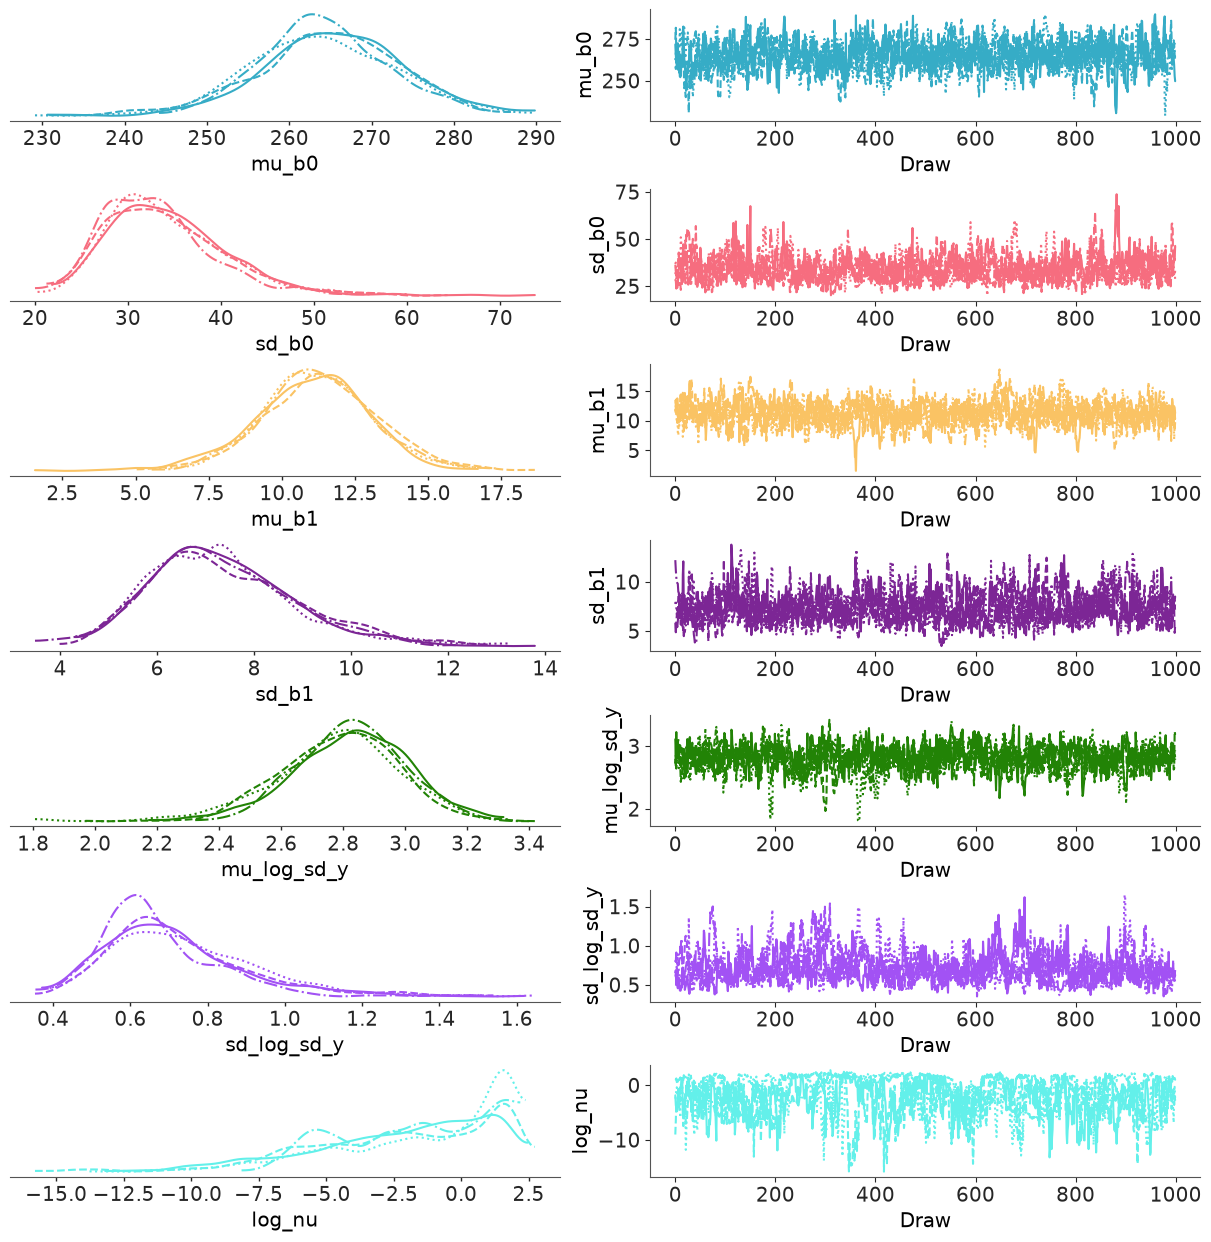

In [11]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "log_nu"],
);

### 3.3 What does "reached the maximum tree depth" mean?

To make each draw, PyMC's sampler follows a simulated path through the parameter space, steered at each step by the slope (the gradient) of the log posterior density, in steps of the size chosen during tuning (Notebook 8), doubling the path's length until the path starts to turn back on itself. The maximum tree depth, 10, caps a path at $2^{10} - 1 = 1{,}023$ steps. Reaching it on almost every draw means the steps are far too small for the distance a path needs to cover. Every draw then costs 1,023 steps, each needing a gradient evaluation, which makes sampling slow, and successive draws still lie close together, which makes the effective sample size low.

The warning's suggestion to increase `target_accept` would make the steps smaller still, which is why Notebook 9's `target_accept=0.99` makes this model sample worse (Question 3.1). Neither setting removes the cause, which Section 4 examines.

### 3.4 Do the population-level parameters meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces. Read the warnings printed by the sampling cell as well as the summary, and compare the sampling time with Notebook 9's, about half a minute.

No. There are no divergences, but that is the only criterion clearly met. PyMC warns that every chain reached the maximum tree depth, and the printout shows that essentially every draw did. R-hat is 1.02 for `mu_log_sd_y` and 1.03 for `sd_log_sd_y` and `log_nu`, and the other parameters sit at the limit of 1.01. `log_nu` has only about 110 bulk and 120 tail effective draws out of 4,000, and `sd_log_sd_y` has only about 170 bulk effective draws; `log_nu`'s trace wanders slowly between about −15 and 3 instead of mixing quickly, and its four chains give visibly different densities. Sampling took between five and six minutes, roughly ten times as long as in Notebook 9.

Zero divergences is therefore not a clean bill of health: a sampler can fail without diverging.

### 3.5 Screen all participants.

The screen lists the five participant-level parameters with the smallest bulk ESS.

In [12]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    kind="diagnostics",
    round_to=2,
)
participant_diagnostics.sort_values("ess_bulk").head()

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b1[332],100.85,241.34,1.04,0.52,0.14
b0[372],116.07,298.68,1.03,0.88,0.34
b1[309],133.99,254.17,1.04,0.09,0.05
b0[309],140.28,277.35,1.04,0.38,0.18
b1[372],148.45,282.08,1.03,0.18,0.09


### 3.6 Plot the traces of the participant with the worst diagnostics.

Plot `b0`, `b1`, and `log_sd_y` for the participant in the first row of the screen, using `azp.plot_trace_dist` and selecting the participant with `coords`.

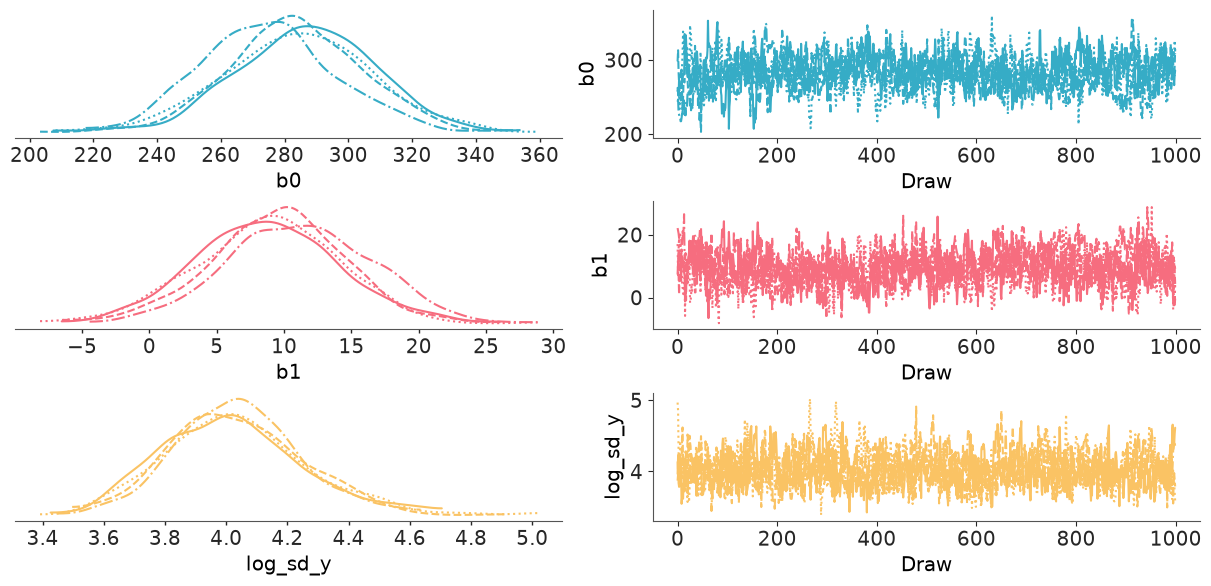

In [13]:
azp.plot_trace_dist(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    coords={"participant": ["332"]},
);

### 3.7 Do the participant-level parameters meet the diagnostic criteria?

No. The five parameters with the smallest bulk ESS belong to three participants, 332, 372, and 309, with bulk ESS of only about 100–150 from 4,000 draws and R-hat of 1.03–1.04. For participant 332, the chains' densities for `b0` and `b1` do not coincide: one chain puts `b0` about 10 ms lower and `b1` about 2 ms/day higher than the other three.

The failure is therefore not confined to the tail: several participants' parameters mix poorly too.

## 4. Examine the failed fit

### 4.1 Plot the posterior distribution of the population-average daily effect.

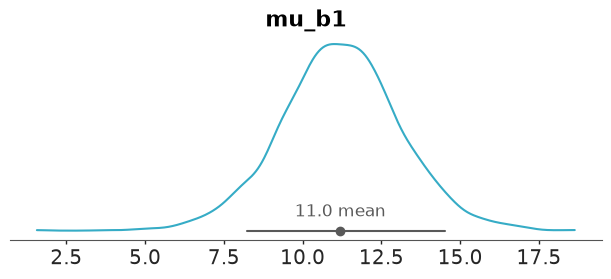

In [14]:
azp.plot_dist(
    idata,
    var_names=["mu_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.2 Would it be safe to report this interval?

Compare the 90% HDI with Notebook 9's, about 8.0–14.6 ms/day, and look at `mu_b1`'s own diagnostics in the summary of Question 3.2.

No, although it looks safe, and that is the danger. The 90% HDI for `mu_b1`, about 8.2–14.5 ms/day, is close to Notebook 9's, and `mu_b1`'s own R-hat (1.01) and ESS (about 580 bulk and 820 tail) would pass on their own. But all parameters are sampled together, and `mu_b1` is the center of the participants' `b1` values, including `b1[332]`, the worst-mixing parameter in the screen (Question 3.7). Chains that have not explored the posterior of `log_nu` or of participant 332 have not explored the joint posterior either, so nothing guarantees that the parts that look fine are right. With Notebook 9's `target_accept=0.99`, this model's chains did not agree even on `mu_b1`.

In a real analysis there would also be no Notebook 9 to compare with. The diagnostics are checked for the whole fit before any posterior quantity is interpreted.

### 4.3 Compare the priors and posteriors of `mu_log_sd_y` and `log_nu`.

A fit that fails its diagnostics is neither reported nor used for predictions, which is why this notebook has no posterior predictive check. Its draws can still show, roughly, where the data and where the prior shaped the posterior, and that helps explain the failure.

Both parameters have the same naive prior, $\operatorname{Normal}(0, 5)$. `azp.plot_prior_posterior` draws a parameter's prior and posterior in one panel. It reads both from one `DataTree`, so first add the prior draws of Question 2.2 to `idata` with `idata["prior"] = prior["prior"]`.

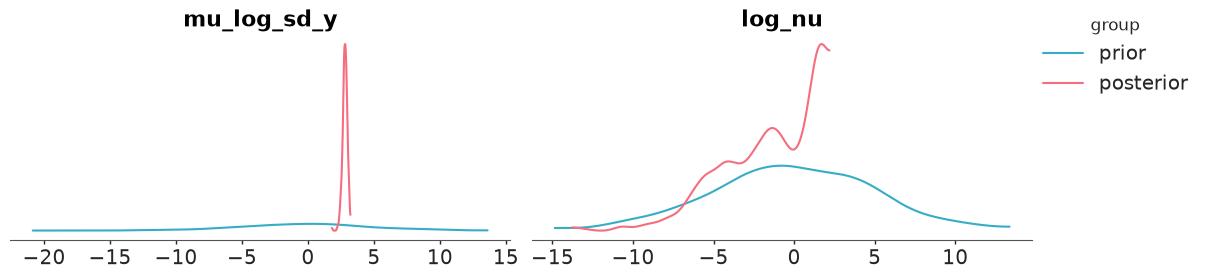

In [15]:
idata["prior"] = prior["prior"]

azp.plot_prior_posterior(idata, var_names=["mu_log_sd_y", "log_nu"]);

### 4.4 What did the data determine, and what did the prior?

Why does the same prior end up so differently in the two panels? Translate the 90% HDI of `log_nu` from the summary in Question 3.2 into milliseconds and compare it with Notebook 9's 90% HDI for `nu`, about 3.7–11 ms.

For `mu_log_sd_y`, the data override the prior: the posterior is a narrow peak near 2.8, a typical Gaussian standard deviation of about $e^{2.8} \approx 16$ ms, essentially Notebook 9's. How widely reaction times scatter around each participant's trajectory is informed by all 144 observations.

For `log_nu`, the data only cut off the right side. The 90% HDI, about −6.4 to 2.2, corresponds to tail means between $e^{-6.4} \approx 0.002$ ms and $e^{2.2} \approx 9$ ms. The upper end is close to Notebook 9's: even these poorly mixed draws agree with Notebook 9's well-sampled fit that the tail is at most about ten milliseconds. Below that, they say little. They favor tails of a few milliseconds only slightly over shorter ones, and not at all once the tail is far shorter than every participant's Gaussian standard deviation, where the ex-Gaussian is indistinguishable from a Gaussian (Notebook 9, Question 4.4).

In Notebook 9, the lower tail of the prior stopped the posterior near 4 ms. This prior puts half its probability below 1 ms, so nothing stops the posterior, whose left side follows the prior's shape; its bumps reflect the small effective sample size, not real features. The prior's pull shows in the summary: the mean of `log_nu`, about −1.9, sits where the prior put its mass, not where the data point.

### 4.5 Why does the sampler struggle with this posterior?

In much of the posterior for `log_nu`, the tail is far shorter than every participant's Gaussian standard deviation (Question 4.4). There, PyMC 6.3.2 computes the ex-Gaussian density with the plain Gaussian formula, switching once $\nu$ falls below 5% of a participant's $sd_y$. At each participant's switch, the log posterior density jumps slightly: far too little to count as a divergence, but a path steered by slopes cannot see a jump coming. These jumps lie in the range of `log_nu` that the sampler's paths keep crossing. The sampler cannot follow the jumps accurately and, during tuning, responds as it does to any inaccuracy: it shrinks its step size, here to a few thousandths (Question 3.2). Because the sampler uses a single step size for the whole posterior (Notebook 8), every parameter then moves slowly. Even a path of 1,023 steps covers only a short distance, so every draw reaches the maximum tree depth and successive draws stay close together (Question 3.3).

These details belong to PyMC's current implementation, and another implementation of the same density could fail differently, for instance with divergences. The cause would be the same: the prior put much of its probability where the data carry no information, and the sampler had to explore all of it. Notebook 9's tail prior kept ν at several milliseconds, above almost every participant's switch, and the same likelihood sampled in half a minute.

## 5. Summary

### 5.1 What has this notebook shown?

Summarize what the naive priors implied, what the prior predictive check showed, how sampling failed, and what the failed fit did and did not determine.

- **Priors.** Written on the log scale and never translated, $\operatorname{Normal}(0, 5)$ and $\operatorname{Exponential}(\mathrm{scale}=5)$ look cautious, but in milliseconds they make specific, implausible claims: a typical Gaussian standard deviation and a typical tail of 1 ms, 95% ranges from about 0.00005 ms to 22 s, and participants whose variability differs by a factor of about 150 per between-participant standard deviation.
- **Prior predictive check.** It exposed the problem before fitting: the plot's axis ran to $10^{51}$ ms, and almost half of the simulated experiments contained a reaction time slower than 10 s.
- **Sampling.** The fit had no divergences, but essentially every draw reached the maximum tree depth, R-hat reached 1.04, the effective sample sizes of `log_nu` and of several participants' parameters were only about 100–150 from 4,000 draws, and sampling took about ten times as long as in Notebook 9. Notebook 9's higher `target_accept` made it worse, not better.
- **Posterior.** The same prior, $\operatorname{Normal}(0, 5)$, was overridden by the data for `mu_log_sd_y`, which all observations inform, and shaped the posterior of `log_nu`, which the data bound only from above, at about ten milliseconds as in Notebook 9; below that, the tail's posterior largely follows the prior. `mu_b1` still looked like Notebook 9's, but a quantity from a fit that fails its diagnostics cannot be reported, however plausible it looks.
- **Units.** A prior is a claim about the quantity it constrains. Behind a log link, a prior that looks vague on the log scale can be extreme in milliseconds, and it does most damage exactly where the data are least informative.